# Hava Kalitesi Verisi: Keşifçi Veri Analizi ve İstatistiksel Anomali Tespiti
Bu çalışma, sensörlerden elde edilen hava kalitesi verilerindeki hatalı ölçümleri temizlemeyi, veriyi görselleştirmeyi ve klasik istatistiksel yöntemler (Z-Skoru, Q-Q Plot) ile anomali (aykırı değer) tespit etmeyi amaçlamaktadır.

# İki Farklı Yaklaşımla İstatistiksel Analiz
Bu projede cihaz kaynaklı eksik veriler (-200) temizlendikten sonra, analiz için **iki farklı senaryo** uygulanmıştır:
1. **Senaryo 1:** Eksik verilerin bulunduğu satırların tamamen silinmesi (Dropna).
2. **Senaryo 2:** Eksik verilerin, ilgili sütunun ortalaması ile doldurulması (Imputation).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

# 1. Ham Veriyi Oku ve Ön Temizlik Yap
data = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')
data = data.dropna(how='all', axis=1).dropna(how='all', axis=0)

# -200 (cihaz hatası) değerlerini NaN yap, gereksiz metin ve boş sütunları at
data = data.replace(-200, np.nan)
data = data.drop(columns=['NMHC(GT)', 'Date', 'Time']) 

# =========================================================
# SENARYO 1: EKSİK VERİLERİ SİLME (Dropna)
# =========================================================
data_silinmis = data.dropna()
print(f"[*] Senaryo 1 (Satırlar Silindi) Veri Boyutu: {data_silinmis.shape}")

# =========================================================
# SENARYO 2: ORTALAMA İLE DOLDURMA (Imputation)
# =========================================================
data_ortalama = data.copy()
for col in data_ortalama.columns:
    col_mean = data_ortalama[col].mean()
    data_ortalama[col] = data_ortalama[col].fillna(col_mean)
    
print(f"[*] Senaryo 2 (Ortalamayla Dolduruldu) Veri Boyutu: {data_ortalama.shape}")

[*] Senaryo 1 (Satırlar Silindi) Veri Boyutu: (6941, 12)
[*] Senaryo 2 (Ortalamayla Dolduruldu) Veri Boyutu: (9357, 12)


---
### Keşifçi Veri Analizi (EDA)
Grafiksel gösterimler, gerçeğe en yakın olan temizlenmiş veri seti (**Senaryo 1**) üzerinden çizdirilmiştir.

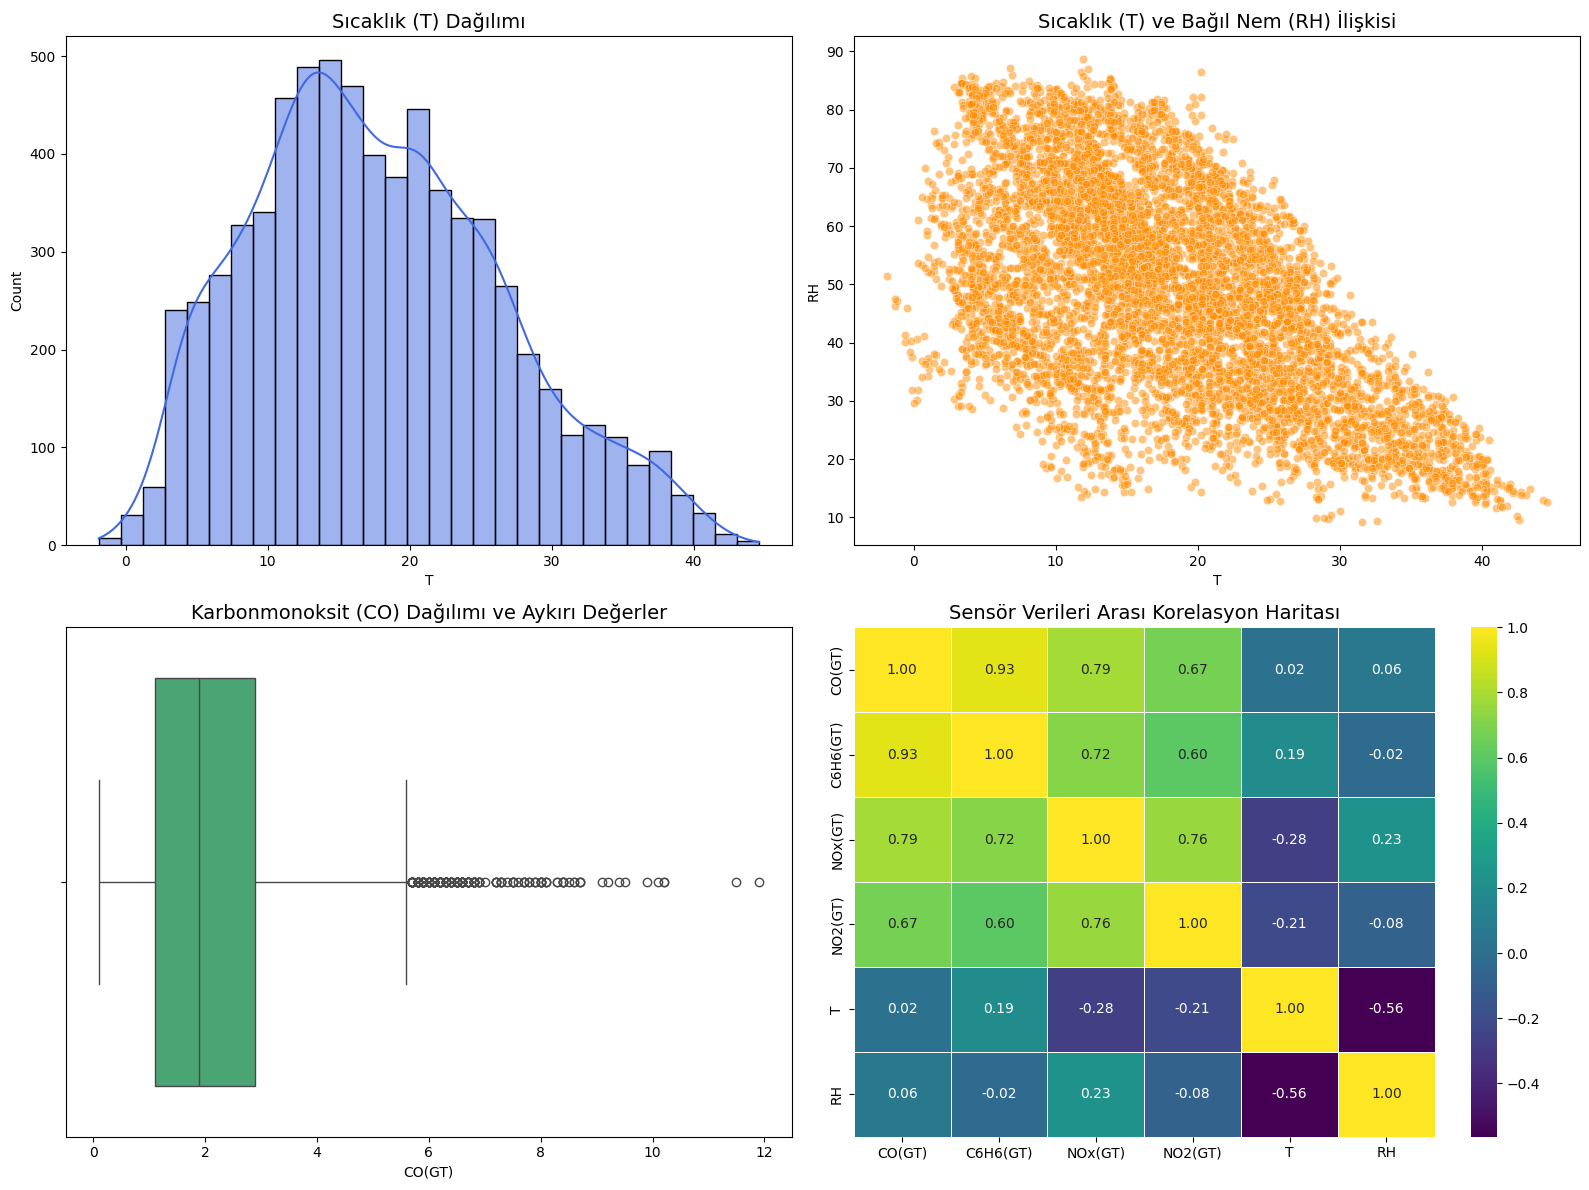

In [2]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# 1. Sıcaklık Histogramı
sns.histplot(data_silinmis['T'], kde=True, bins=30, color='royalblue', ax=axes[0, 0])
axes[0, 0].set_title('Sıcaklık (T) Dağılımı', fontsize=14)

# 2. Scatter Plot
sns.scatterplot(x='T', y='RH', data=data_silinmis, alpha=0.5, color='darkorange', ax=axes[0, 1])
axes[0, 1].set_title('Sıcaklık (T) ve Bağıl Nem (RH) İlişkisi', fontsize=14)

# 3. Boxplot (Anomaliler)
sns.boxplot(x=data_silinmis['CO(GT)'], color='mediumseagreen', ax=axes[1, 0])
axes[1, 0].set_title('Karbonmonoksit (CO) Dağılımı ve Aykırı Değerler', fontsize=14)

# 4. Korelasyon Heatmap
korelasyon = data_silinmis[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH']].corr()
sns.heatmap(korelasyon, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Sensör Verileri Arası Korelasyon Haritası', fontsize=14)

plt.tight_layout()
plt.show()

---
### İstatistiksel Analiz ve Senaryo Karşılaştırması
Aşağıdaki fonksiyon, verilen herhangi bir veri seti için tüm istatistiksel testleri (Parametreler, Z-Skoru, Güven Aralığı, Shapiro-Wilk) otomatik olarak gerçekleştirecektir.

In [3]:
def istatistiksel_analiz_yap(veri_sutunu, senaryo_adi):
    print(f"{'='*60}\n=== {senaryo_adi} ===\n{'='*60}")
    
    # Parametreler
    mu = veri_sutunu.mean()
    sigma = veri_sutunu.std()
    print(f"[*] Ortalama (μ): {mu:.4f}  |  Standart Sapma (σ): {sigma:.4f}\n")

    # Z-Skoru ve 68-95-99.7 Kuralı
    z_scores = (veri_sutunu - mu) / sigma
    oran_1 = len(z_scores[(z_scores >= -1) & (z_scores <= 1)]) / len(z_scores) * 100
    oran_2 = len(z_scores[(z_scores >= -2) & (z_scores <= 2)]) / len(z_scores) * 100
    oran_3 = len(z_scores[(z_scores >= -3) & (z_scores <= 3)]) / len(z_scores) * 100
    print("[*] 68-95-99.7 Kuralı:")
    print(f"    ±1 Std: %{oran_1:.2f}  |  ±2 Std: %{oran_2:.2f}  |  ±3 Std: %{oran_3:.2f}\n")

    # Normallik Testi
    stat, p_value = stats.shapiro(veri_sutunu)
    print(f"[*] Shapiro-Wilk Testi P-Değeri: {p_value:.4e}")
    print("    -> Sonuç: H0 Reddedilir (Veri normal dağılıma uymuyor)\n" if p_value < 0.05 else "    -> Sonuç: H0 Reddedilemez (Veri normal dağılıma uyuyor)\n")

    # Güven Aralığı ve Anomali
    n = len(veri_sutunu)
    standart_hata = sigma / np.sqrt(n)
    alt, ust = stats.norm.interval(0.95, loc=mu, scale=standart_hata)
    
    anomaliler = veri_sutunu[abs(z_scores) > 3]
    print(f"[*] %95 Güven Aralığı: ({alt:.4f}, {ust:.4f})")
    print(f"[*] Tespit Edilen Anomali (|Z| > 3) Sayısı: {len(anomaliler)}\n")
    
    # Q-Q Plot
    plt.figure(figsize=(6, 4))
    stats.probplot(veri_sutunu, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot: {senaryo_adi}")
    plt.show()

**Senaryo 1'in (Satır Silme) Analiz Sonuçları:**

=== SENARYO 1 (EKSİKLER SİLİNDİ) ===
[*] Ortalama (μ): 17.7553  |  Standart Sapma (σ): 8.8449

[*] 68-95-99.7 Kuralı:
    ±1 Std: %66.47  |  ±2 Std: %95.95  |  ±3 Std: %99.97

[*] Shapiro-Wilk Testi P-Değeri: 4.8761e-29
    -> Sonuç: H0 Reddedilir (Veri normal dağılıma uymuyor)

[*] %95 Güven Aralığı: (17.5472, 17.9634)
[*] Tespit Edilen Anomali (|Z| > 3) Sayısı: 2



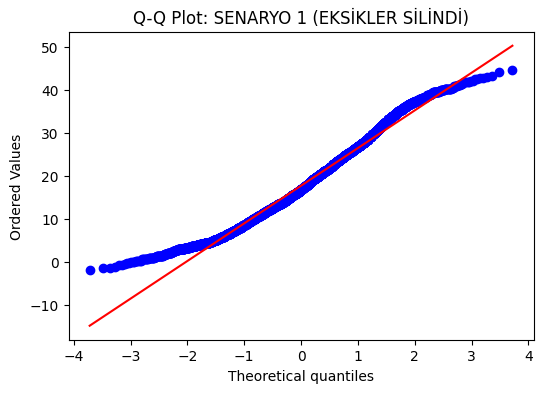

In [4]:
# Sadece eksikleri silinmiş verinin Sıcaklık (T) sütununu analize gönderiyoruz:
istatistiksel_analiz_yap(data_silinmis['T'], "SENARYO 1 (EKSİKLER SİLİNDİ)")

**Senaryo 2'nin (Ortalamayla Doldurma) Analiz Sonuçları:**

=== SENARYO 2 (ORTALAMAYLA DOLDURULDU) ===
[*] Ortalama (μ): 18.3178  |  Standart Sapma (σ): 8.6576

[*] 68-95-99.7 Kuralı:
    ±1 Std: %66.91  |  ±2 Std: %95.93  |  ±3 Std: %99.98

[*] Shapiro-Wilk Testi P-Değeri: 6.3130e-28
    -> Sonuç: H0 Reddedilir (Veri normal dağılıma uymuyor)

[*] %95 Güven Aralığı: (18.1424, 18.4932)
[*] Tespit Edilen Anomali (|Z| > 3) Sayısı: 2



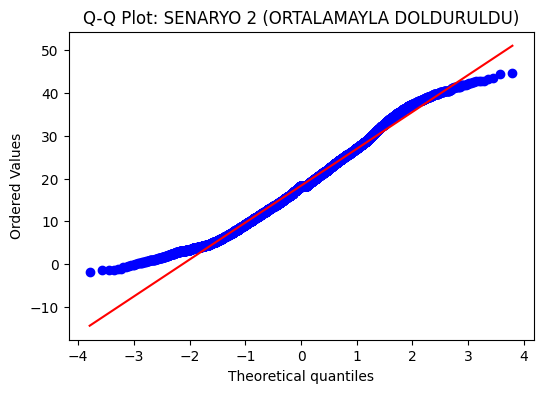

In [5]:
# Ortalamayla doldurulmuş verinin Sıcaklık (T) sütununu analize gönderiyoruz:
istatistiksel_analiz_yap(data_ortalama['T'], "SENARYO 2 (ORTALAMAYLA DOLDURULDU)")